## Importing Modules

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated,Literal
from IPython.display import Image
from dotenv import load_dotenv,find_dotenv
from groq import Groq
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage,BaseMessage
import os
import operator
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver,InMemorySaver
load_dotenv(find_dotenv())

True

In [3]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
       temperature=0
) 

In [4]:
class JokeState(TypedDict):

    topic : str

    joke : str

    explanation : str

In [5]:
def generate_joke(state:JokeState) -> JokeState:
    topic = state['topic']
    joke_prompt = f"Generate a joke about {topic}."
    response = llm.invoke(joke_prompt).content
    return { "joke":response}
   

In [6]:
def generate_explanation(state:JokeState) -> JokeState:
    joke = state['joke']
    explanation_prompt = f"Explain the following joke: {joke}."
    response = llm.invoke(explanation_prompt).content
    return { "explanation":response}

In [7]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke",generate_joke)
graph.add_node("generate_explanation",generate_explanation)

graph.add_edge(START,"generate_joke")
graph.add_edge("generate_joke","generate_explanation")
graph.add_edge("generate_explanation",END)

checkpoint = InMemorySaver()

workflow = graph.compile(checkpointer=checkpoint)

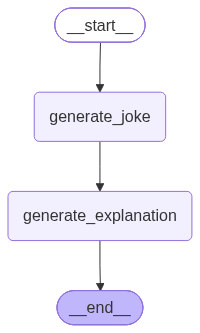

In [8]:
workflow

In [12]:
config1 = {"configurable":{"thread_id":"1"}}
workflow.invoke({"topic":"programming"},config=config1)

{'topic': 'programming',
 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.',
 'explanation': 'A clever joke. The joke is a play on words, using a double meaning of the word "bugs".\n\nIn the context of programming, "bugs" refers to errors or glitches in the code. However, in a literal sense, "bugs" can also refer to insects, which are often attracted to light sources.\n\nThe joke is saying that programmers prefer dark mode (a display setting with a dark background and light text) because "light attracts bugs". This is a pun, as it can be interpreted in two ways:\n\n1. Light attracts insects (the literal meaning of "bugs").\n2. Light (or, in this case, a light-colored display) attracts coding errors or glitches (the programming meaning of "bugs").\n\nThe joke is humorous because it takes a common phrase and gives it a clever, unexpected twist, using the dual meaning of the word "bugs" to create a wordplay.'}

In [15]:
workflow.get_state(config=config1)

StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', 'explanation': 'A clever joke. The joke is a play on words, using a double meaning of the word "bugs".\n\nIn the context of programming, "bugs" refers to errors or glitches in the code. However, in a literal sense, "bugs" can also refer to insects, which are often attracted to light sources.\n\nThe joke is saying that programmers prefer dark mode (a display setting with a dark background and light text) because "light attracts bugs". This is a pun, as it can be interpreted in two ways:\n\n1. Light attracts insects (the literal meaning of "bugs").\n2. Light (or, in this case, a light-colored display) attracts coding errors or glitches (the programming meaning of "bugs").\n\nThe joke is humorous because it takes a common phrase and gives it a clever, unexpected twist, using the dual meaning of the word "bugs" to create a wordplay.'}, next=(), config={'configurable

In [ ]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', 'explanation': 'A clever joke. The joke is a play on words, using a double meaning of the word "bugs".\n\nIn the context of programming, "bugs" refers to errors or glitches in the code. However, in a literal sense, "bugs" can also refer to insects, which are often attracted to light sources.\n\nThe joke is saying that programmers prefer dark mode (a display setting with a dark background and light text) because "light attracts bugs". This is a pun, as it can be interpreted in two ways:\n\n1. Light attracts insects (the literal meaning of "bugs").\n2. Light (or, in this case, a light-colored display) attracts coding errors or glitches (the programming meaning of "bugs").\n\nThe joke is humorous because it takes a common phrase and gives it a clever, unexpected twist, using the dual meaning of the word "bugs" to create a wordplay.'}, next=(), config={'configurabl

: 

In [14]:
config2 = {"configurable":{"thread_id":"2"}}
workflow.invoke({"topic":"Biryani"},config=config2)

{'topic': 'Biryani',
 'joke': 'Why did the Biryani go to therapy?\n\nBecause it was feeling a little "mixed up"! (get it? like the mix of spices and ingredients in Biryani?)',
 'explanation': 'A clever joke. Let\'s break it down:\n\nThe joke is a play on words, using a common phrase "mixed up" in a double sense:\n\n1. **Emotional state**: "Mixed up" is an idiomatic expression that means feeling confused, disoriented, or emotionally unstable. It\'s a common reason why someone might go to therapy.\n2. **Culinary reference**: Biryani is a popular South Asian dish made with a mixture of spices, basmati rice, and various ingredients (e.g., meat, vegetables). The phrase "mixed up" also literally refers to the combination of these ingredients in the dish.\n\nThe joke relies on this wordplay, using the phrase "mixed up" to create a humorous connection between the emotional state of the Biryani (going to therapy) and its culinary characteristics (being a mix of ingredients). The punchline is a 